# Q-Learning Agent — Pathfinding on Grid World

This notebook trains a **Q-Learning** agent on a random grid world and visualizes:
- Environment layout
- Learning curves (reward, success rate)
- Q-value heatmaps
- Learned policy (arrows)
- Final greedy path
- Dynamic animation of path discovery across training

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from IPython.display import display, clear_output
import time

from src.environment import GridWorld
from src.agents.q_learning import QLearningAgent
from src.trainer import train_agent, extract_greedy_path
from src.metrics import compute_metrics

%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 8)
plt.rcParams['figure.dpi'] = 100

## 1. Environment Setup

In [2]:
# Create environment
GRID_SIZE = 15
OBSTACLE_DENSITY = 0.25
SEED = 42

env = GridWorld(size=GRID_SIZE, obstacle_density=OBSTACLE_DENSITY, seed=SEED)
optimal_length = env.get_optimal_path_length()

print(f"Grid size: {env.size}x{env.size}")
print(f"Start: {env.start}")
print(f"Goal: {env.goal}")
print(f"Obstacles: {np.sum(env.grid == 1)}")
print(f"Optimal path length: {optimal_length}")

Grid size: 15x15
Start: (1, 9)
Goal: (6, 12)
Obstacles: 56
Optimal path length: 8


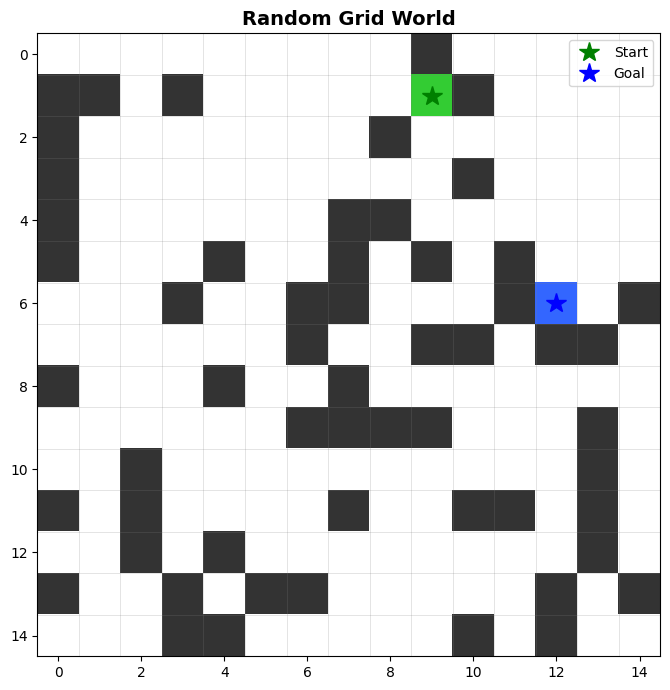

In [3]:
def show_grid(env, path=None, title="Grid World"):
    size = env.size
    fig, ax = plt.subplots(figsize=(7, 7))
    display_grid = np.zeros((size, size, 3))
    for r in range(size):
        for c in range(size):
            if env.grid[r, c] == 1:
                display_grid[r, c] = [0.2, 0.2, 0.2]
            elif env.grid[r, c] == 2:
                display_grid[r, c] = [0.2, 0.8, 0.2]
            elif env.grid[r, c] == 3:
                display_grid[r, c] = [0.2, 0.4, 1.0]
            else:
                display_grid[r, c] = [1.0, 1.0, 1.0]
    if path and len(path) > 1:
        for i, (r, c) in enumerate(path):
            if env.grid[r, c] == 0:
                t = i / max(len(path) - 1, 1)
                display_grid[r, c] = [1.0 - 0.6*t, 1.0 - 0.3*t, 0.8 - 0.8*t]
    ax.imshow(display_grid, interpolation='nearest')
    for i in range(size + 1):
        ax.axhline(i - 0.5, color='gray', linewidth=0.5, alpha=0.3)
        ax.axvline(i - 0.5, color='gray', linewidth=0.5, alpha=0.3)
    if path and len(path) > 1:
        for i in range(len(path) - 1):
            ax.annotate('', xy=(path[i+1][1], path[i+1][0]),
                        xytext=(path[i][1], path[i][0]),
                        arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
    ax.plot(env.start[1], env.start[0], 'g*', markersize=15, label='Start')
    ax.plot(env.goal[1], env.goal[0], 'b*', markersize=15, label='Goal')
    if path:
        ax.plot(path[-1][1], path[-1][0], 'ro', markersize=10, label='End')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

show_grid(env, title="Random Grid World")

## 2. Train Q-Learning Agent

In [4]:
# Hyperparameters
NUM_EPISODES = 500
MAX_STEPS = 500
ALPHA = 0.1
GAMMA = 0.95
EPSILON_DECAY = 0.995

agent = QLearningAgent(
    num_states=env.num_states,
    num_actions=env.num_actions,
    alpha=ALPHA,
    gamma=GAMMA,
    epsilon_decay=EPSILON_DECAY
)

print(f"Training Q-Learning for {NUM_EPISODES} episodes...")
start = time.time()
results = train_agent(env, agent, num_episodes=NUM_EPISODES,
                      max_steps=MAX_STEPS, seed=SEED)
elapsed = time.time() - start
print(f"Training complete in {elapsed:.2f}s")
print(f"Best path found: {results['best_path_steps']} steps")
print(f"Optimal path: {optimal_length} steps")

Training Q-Learning for 500 episodes...
Training complete in 0.03s
Best path found: 8 steps
Optimal path: 8 steps


## 3. Learning Curves

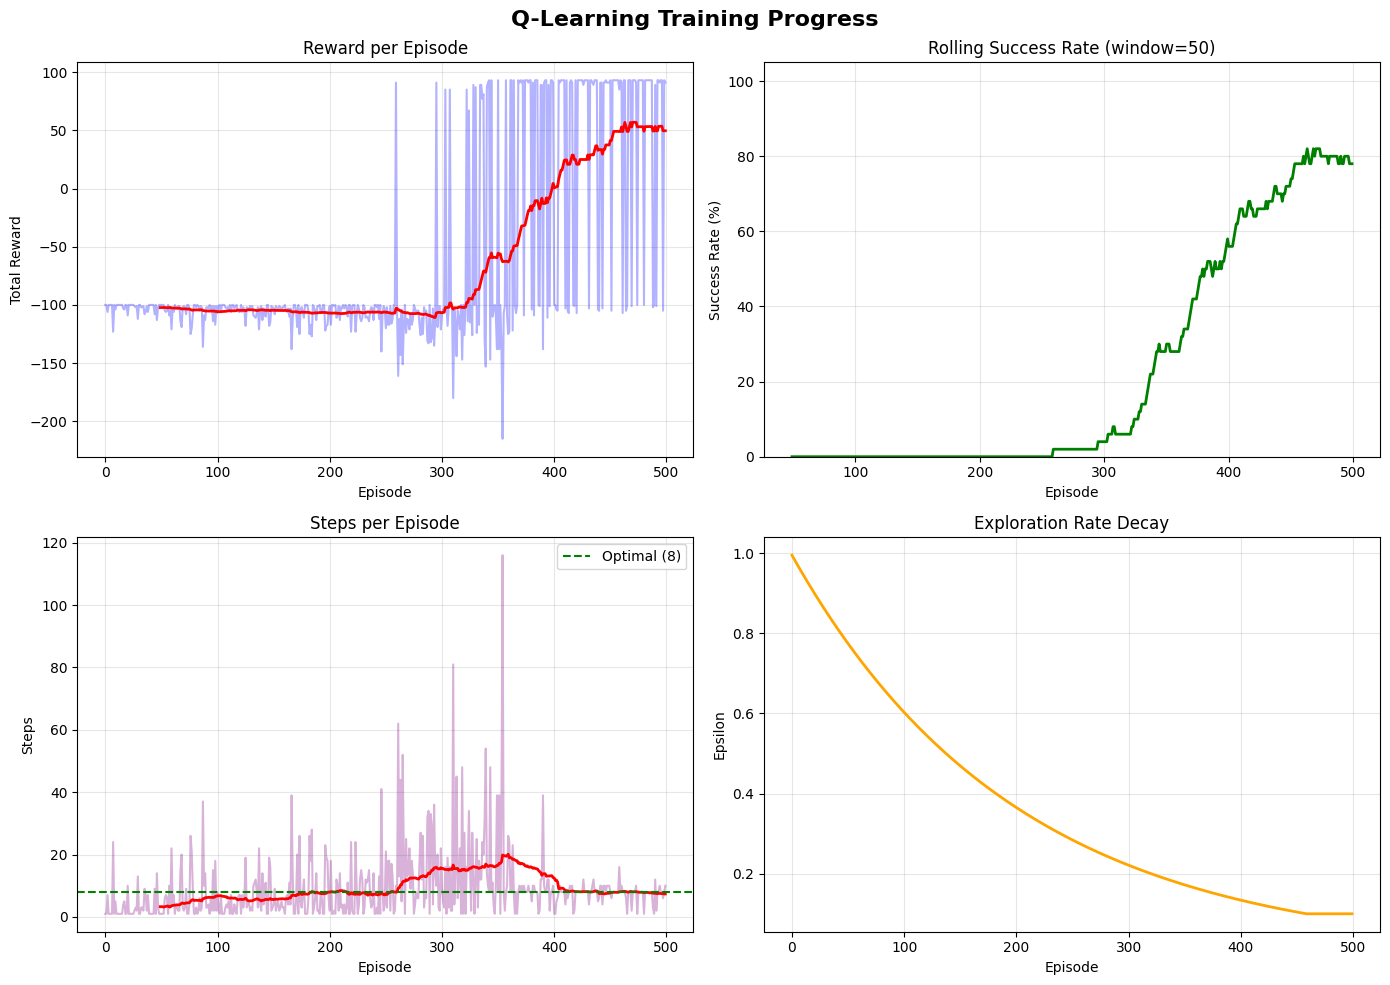

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Reward per episode
axes[0, 0].plot(results['rewards'], alpha=0.3, color='blue')
window = 50
smooth = np.convolve(results['rewards'], np.ones(window)/window, mode='valid')
axes[0, 0].plot(range(window-1, NUM_EPISODES), smooth, color='red', linewidth=2)
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Total Reward')
axes[0, 0].set_title('Reward per Episode')
axes[0, 0].grid(True, alpha=0.3)

# Success rate (rolling)
success_smooth = np.convolve(results['success'], np.ones(window)/window, mode='valid')
axes[0, 1].plot(range(window-1, NUM_EPISODES), success_smooth * 100, color='green', linewidth=2)
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Success Rate (%)')
axes[0, 1].set_title(f'Rolling Success Rate (window={window})')
axes[0, 1].set_ylim(0, 105)
axes[0, 1].grid(True, alpha=0.3)

# Steps per episode
axes[1, 0].plot(results['steps'], alpha=0.3, color='purple')
step_smooth = np.convolve(results['steps'], np.ones(window)/window, mode='valid')
axes[1, 0].plot(range(window-1, NUM_EPISODES), step_smooth, color='red', linewidth=2)
axes[1, 0].axhline(y=optimal_length, color='green', linestyle='--', label=f'Optimal ({optimal_length})')
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('Steps')
axes[1, 0].set_title('Steps per Episode')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Epsilon decay
axes[1, 1].plot(results['epsilons'], color='orange', linewidth=2)
axes[1, 1].set_xlabel('Episode')
axes[1, 1].set_ylabel('Epsilon')
axes[1, 1].set_title('Exploration Rate Decay')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Q-Learning Training Progress', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Q-Value Heatmap

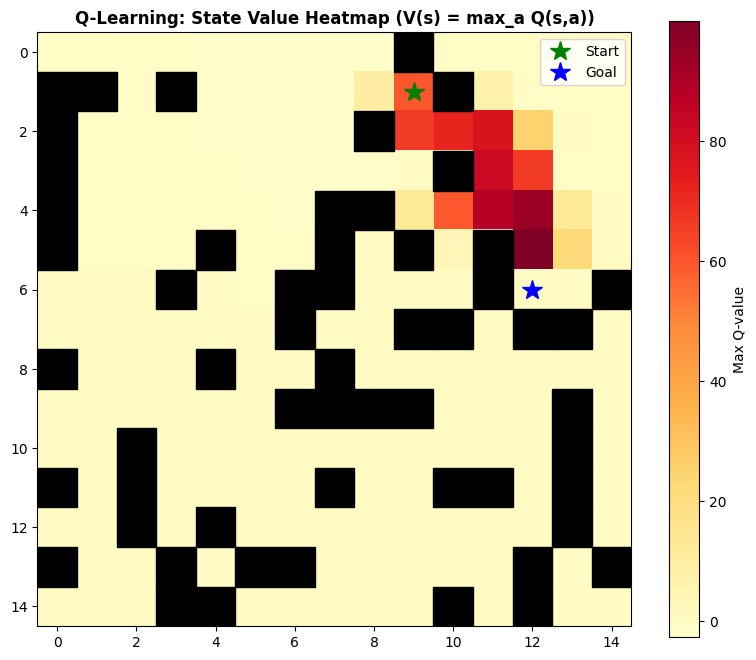

In [6]:
state_values = np.max(agent.q_table, axis=1).reshape(env.size, env.size)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(state_values, cmap='YlOrRd', interpolation='nearest')

# Mask obstacles
for r in range(env.size):
    for c in range(env.size):
        if env.grid[r, c] == 1:
            ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color='black'))

ax.plot(env.start[1], env.start[0], 'g*', markersize=15, label='Start')
ax.plot(env.goal[1], env.goal[0], 'b*', markersize=15, label='Goal')
plt.colorbar(im, ax=ax, label='Max Q-value', shrink=0.8)
ax.set_title('Q-Learning: State Value Heatmap (V(s) = max_a Q(s,a))', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Learned Policy (Arrow Visualization)

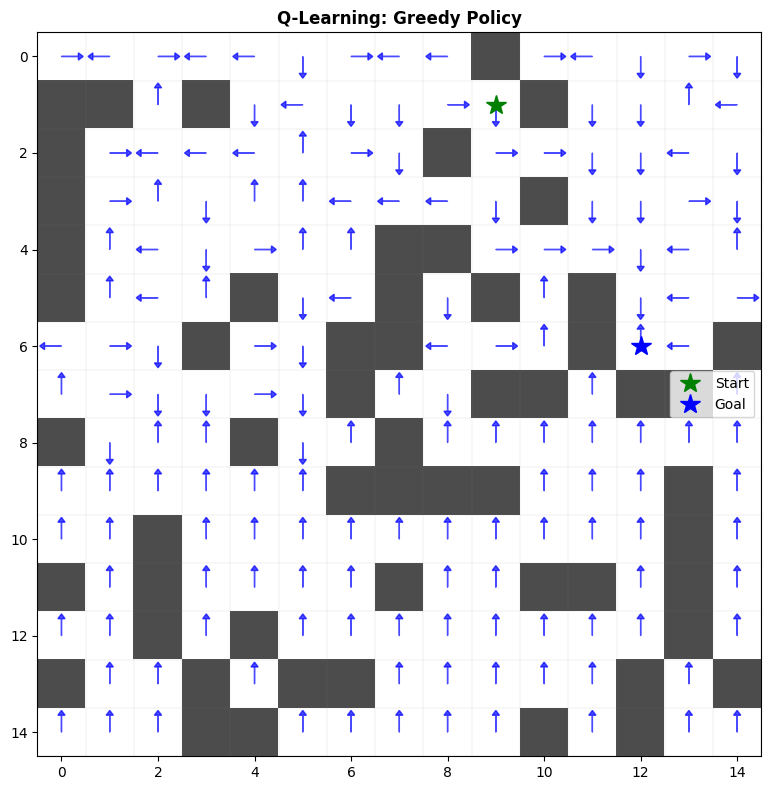

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))
display_grid = np.ones((env.size, env.size, 3))
for r in range(env.size):
    for c in range(env.size):
        if env.grid[r, c] == 1:
            display_grid[r, c] = [0.3, 0.3, 0.3]
ax.imshow(display_grid, interpolation='nearest')

arrow_map = {0: (0, -0.35), 1: (0, 0.35), 2: (-0.35, 0), 3: (0.35, 0)}
action_labels = {0: '↑', 1: '↓', 2: '←', 3: '→'}

for s in range(env.num_states):
    pos = env.state_to_pos(s)
    if env.grid[pos] == 1:
        continue
    best_action = np.argmax(agent.q_table[s])
    dx, dy = arrow_map[best_action]
    ax.arrow(pos[1], pos[0], dx, dy, head_width=0.15, head_length=0.1,
             fc='blue', ec='blue', alpha=0.7)

for i in range(env.size + 1):
    ax.axhline(i - 0.5, color='gray', linewidth=0.3, alpha=0.3)
    ax.axvline(i - 0.5, color='gray', linewidth=0.3, alpha=0.3)

ax.plot(env.start[1], env.start[0], 'g*', markersize=15, label='Start')
ax.plot(env.goal[1], env.goal[0], 'b*', markersize=15, label='Goal')
ax.set_title('Q-Learning: Greedy Policy', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Final Greedy Path

Greedy path length: 8 steps
Optimal path length: 8 steps
Agent successfully reached the goal!


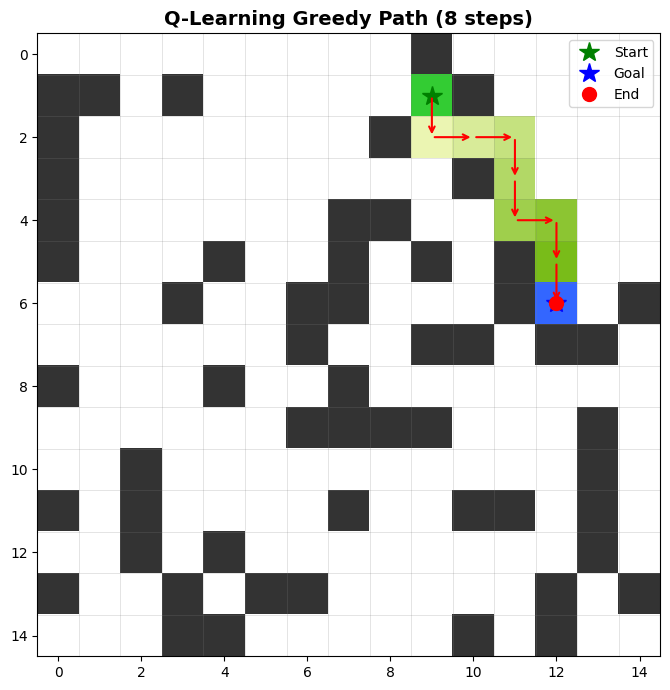

In [8]:
greedy_path = extract_greedy_path(env, agent)
print(f"Greedy path length: {len(greedy_path) - 1} steps")
print(f"Optimal path length: {optimal_length} steps")
if greedy_path[-1] == env.goal:
    print("Agent successfully reached the goal!")
else:
    print("Agent did not reach the goal.")

show_grid(env, path=greedy_path, title=f"Q-Learning Greedy Path ({len(greedy_path)-1} steps)")

## 7. Dynamic Path Discovery Animation

This cell trains a fresh agent and animates the best path found after every N episodes.

In [9]:
from IPython.display import HTML
import matplotlib.animation as animation

# Re-train with snapshots
env_anim = GridWorld(size=GRID_SIZE, obstacle_density=OBSTACLE_DENSITY, seed=SEED)
agent_anim = QLearningAgent(
    num_states=env_anim.num_states, num_actions=env_anim.num_actions,
    alpha=ALPHA, gamma=GAMMA, epsilon_decay=EPSILON_DECAY
)

SNAP_EVERY = 10  # snapshot every N episodes
snapshots = []  # list of (episode, path, reward, success_rate)

np.random.seed(SEED)
agent_anim.reset()
all_rewards = []
all_success = []
best_path_snap = None
best_steps_snap = float('inf')

for ep in range(NUM_EPISODES):
    state = env_anim.reset()
    total_reward = 0.0
    path = [env_anim.agent_pos]
    for s in range(MAX_STEPS):
        action = agent_anim.select_action(state)
        next_state, reward, done = env_anim.step(action)
        agent_anim.update(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        path.append(env_anim.agent_pos)
        if done:
            break
    agent_anim.decay_epsilon()
    success = (env_anim.agent_pos == env_anim.goal)
    all_rewards.append(total_reward)
    all_success.append(success)
    if success and len(path) - 1 < best_steps_snap:
        best_steps_snap = len(path) - 1
        best_path_snap = path.copy()
    if (ep + 1) % SNAP_EVERY == 0:
        window = min(50, len(all_success))
        sr = np.mean(all_success[-window:]) * 100
        snapshots.append({
            'episode': ep + 1,
            'path': best_path_snap.copy() if best_path_snap else None,
            'best_steps': best_steps_snap,
            'success_rate': sr,
            'avg_reward': np.mean(all_rewards[-window:])
        })

print(f"Captured {len(snapshots)} snapshots")
print(f"Final best path: {best_steps_snap} steps (optimal: {optimal_length})")

Captured 50 snapshots
Final best path: 8 steps (optimal: 8)


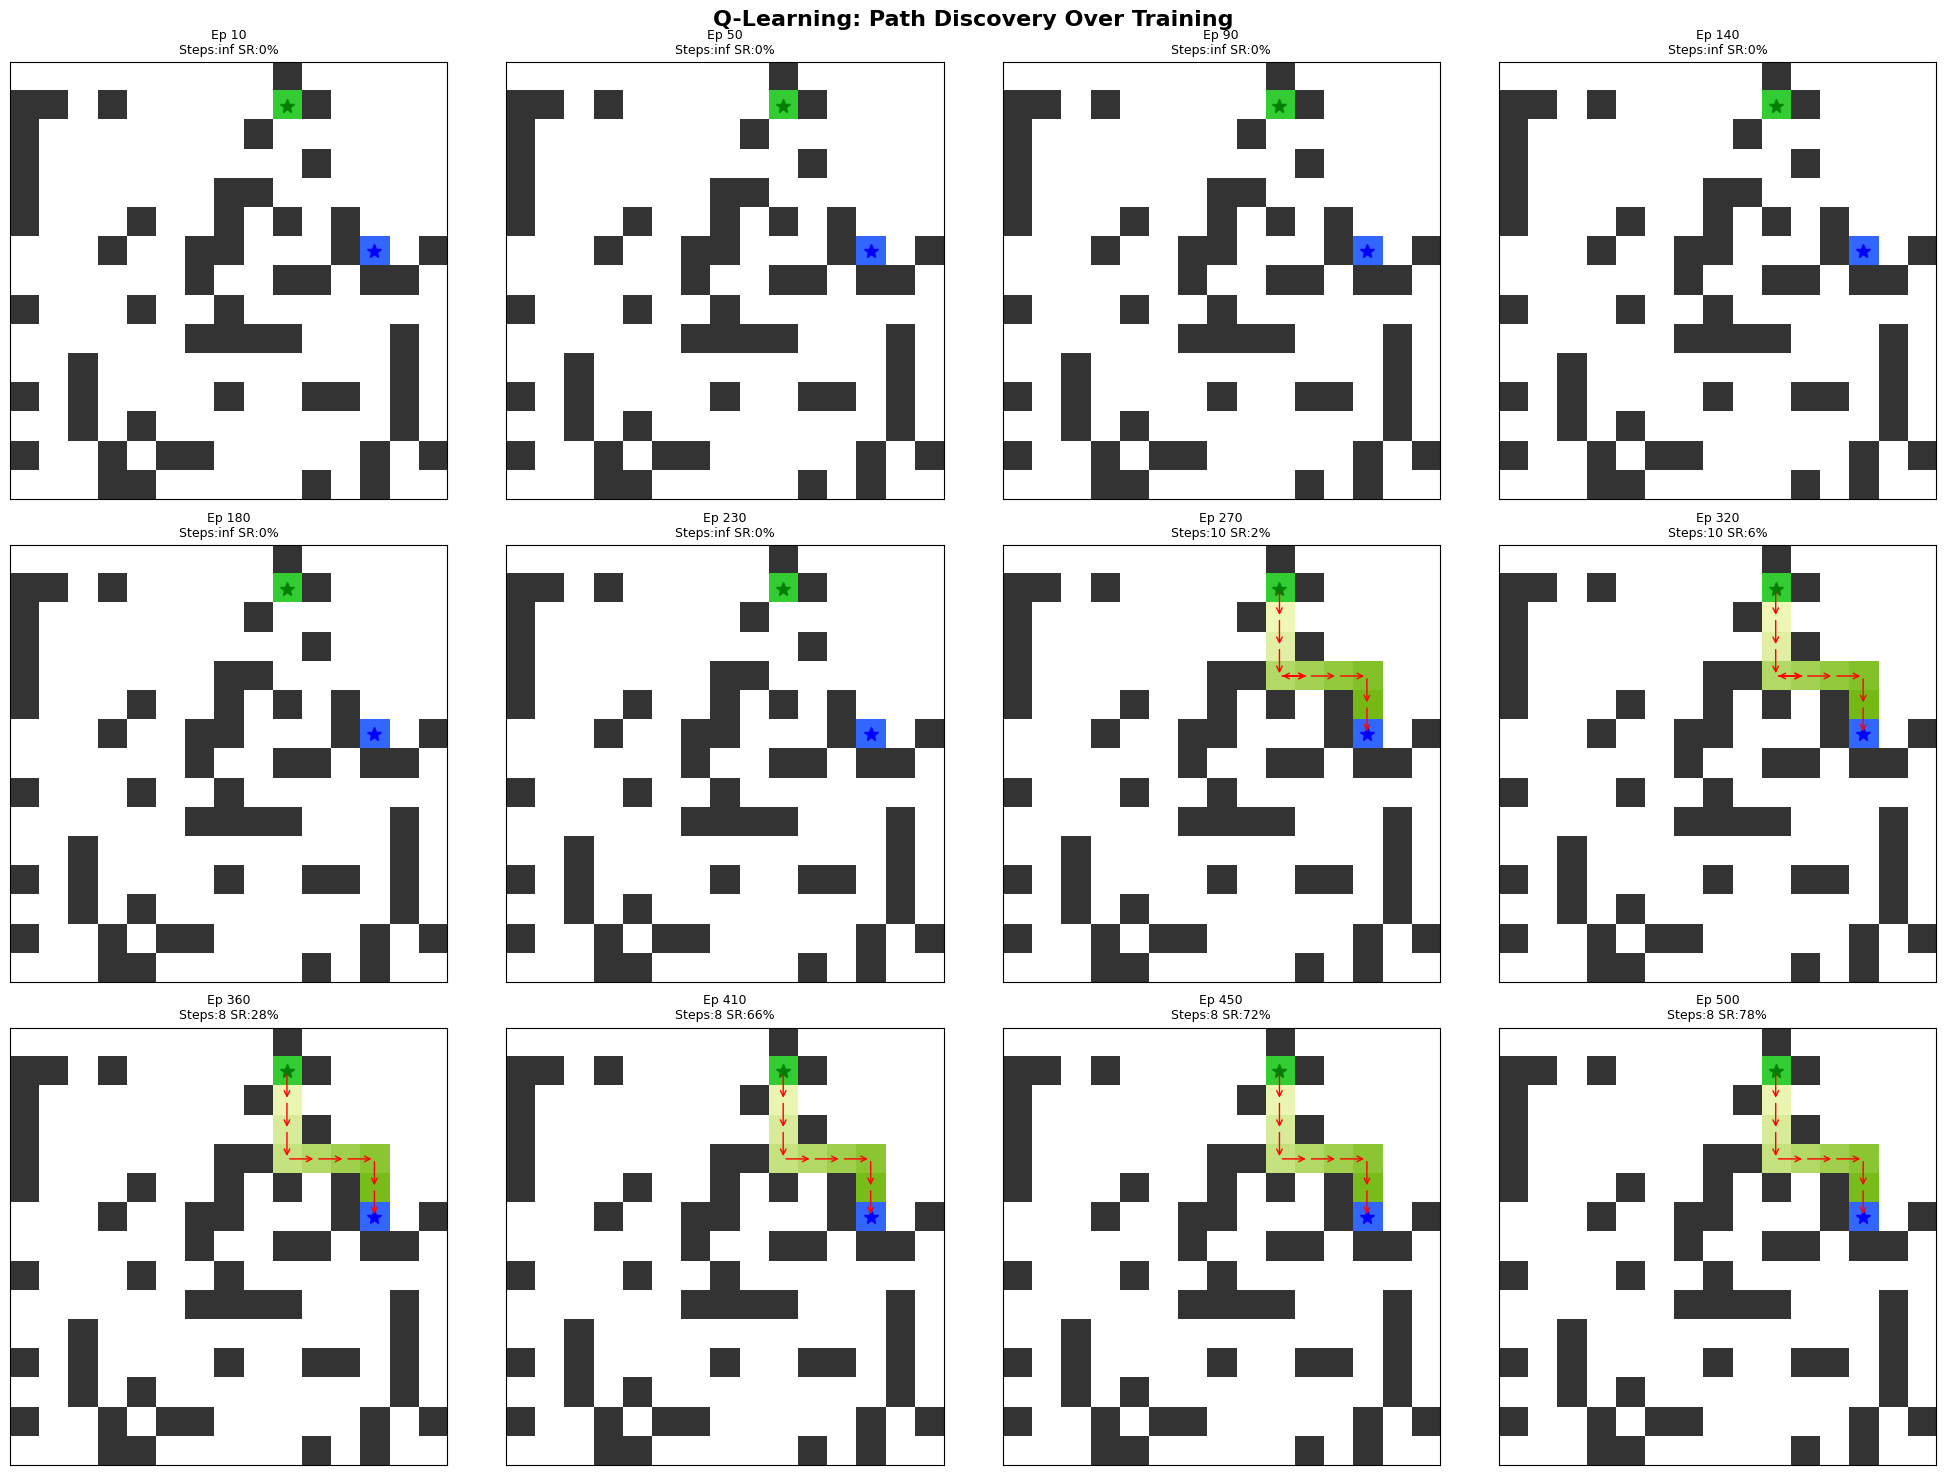

In [10]:
# Display snapshots as a grid of subplots
n_snaps = min(len(snapshots), 12)
indices = np.linspace(0, len(snapshots)-1, n_snaps, dtype=int)

cols = 4
rows = (n_snaps + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
axes = axes.flatten() if n_snaps > 1 else [axes]

for idx, ax_idx in enumerate(indices):
    snap = snapshots[ax_idx]
    ax = axes[idx]
    size = env_anim.size
    display_grid = np.zeros((size, size, 3))
    for r in range(size):
        for c in range(size):
            if env_anim.grid[r, c] == 1:
                display_grid[r, c] = [0.2, 0.2, 0.2]
            elif env_anim.grid[r, c] == 2:
                display_grid[r, c] = [0.2, 0.8, 0.2]
            elif env_anim.grid[r, c] == 3:
                display_grid[r, c] = [0.2, 0.4, 1.0]
            else:
                display_grid[r, c] = [1.0, 1.0, 1.0]
    path = snap['path']
    if path and len(path) > 1:
        for i, (r, c) in enumerate(path):
            if env_anim.grid[r, c] == 0:
                t = i / max(len(path) - 1, 1)
                display_grid[r, c] = [1.0-0.6*t, 1.0-0.3*t, 0.8-0.8*t]
    ax.imshow(display_grid, interpolation='nearest')
    if path and len(path) > 1:
        for i in range(len(path) - 1):
            ax.annotate('', xy=(path[i+1][1], path[i+1][0]),
                        xytext=(path[i][1], path[i][0]),
                        arrowprops=dict(arrowstyle='->', color='red', lw=1))
    ax.plot(env_anim.start[1], env_anim.start[0], 'g*', markersize=10)
    ax.plot(env_anim.goal[1], env_anim.goal[0], 'b*', markersize=10)
    ax.set_title(f"Ep {snap['episode']}\nSteps:{snap['best_steps']} SR:{snap['success_rate']:.0f}%",
                 fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

# Hide unused axes
for idx in range(n_snaps, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Q-Learning: Path Discovery Over Training', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Summary Statistics

In [11]:
metrics = compute_metrics(results, optimal_length)

print("=" * 50)
print("Q-Learning Agent — Summary")
print("=" * 50)
print(f"Total Episodes:          {metrics['total_episodes']}")
print(f"Overall Success Rate:    {metrics['overall_success_rate']*100:.1f}%")
print(f"Final Success Rate:      {metrics['final_success_rate']*100:.1f}%")
print(f"Best Path Steps:         {metrics['best_path_steps']}")
print(f"Optimal Path Steps:      {optimal_length}")
print(f"Optimality Ratio:        {metrics['optimality_ratio']:.2f}x")
print(f"Convergence Episode:     {metrics['convergence_episode']}")
print(f"Training Time:           {metrics['training_time']:.2f}s")
print(f"Final Avg Reward:        {metrics['final_avg_reward']:.1f}")
print(f"Final Avg Steps:         {metrics['final_avg_steps']:.1f} +/- {metrics['final_std_steps']:.1f}")

Q-Learning Agent — Summary
Total Episodes:          500
Overall Success Rate:    24.0%
Final Success Rate:      75.0%
Best Path Steps:         8
Optimal Path Steps:      8
Optimality Ratio:        1.00x
Convergence Episode:     500
Training Time:           0.03s
Final Avg Reward:        43.5
Final Avg Steps:         7.5 +/- 2.7
